In [1]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

# Загружаем данные
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target

In [2]:
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


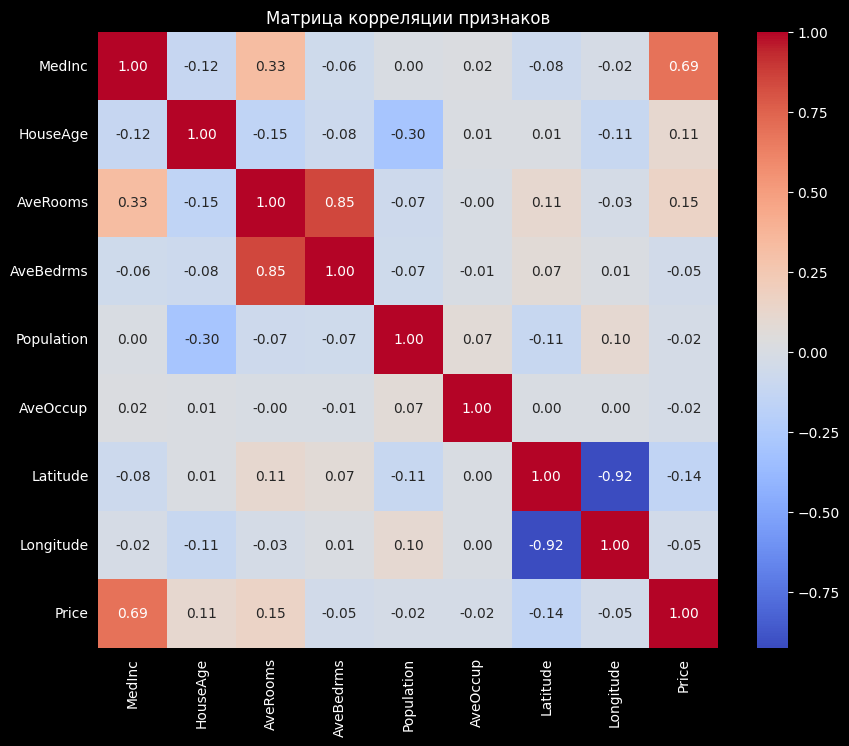

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Считаем корреляцию
corr_matrix = df.corr()

# Рисуем карту
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Матрица корреляции признаков')
plt.show()

In [6]:
from sklearn.model_selection import train_test_split

# X - это признаки (все колонки кроме Price)
# y - это целевая переменная (Price)
X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (16512, 8)
Размер тестовой выборки: (4128, 8)


In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Инициализируем и обучаем
model = LinearRegression()
model.fit(X_train, y_train)

# Делаем предсказание на тестовых данных
predictions = model.predict(X_test)

# Считаем метрики
print(f"R^2 Score: {r2_score(y_test, predictions):.4f}")
print(f"MSE: {mean_squared_error(y_test, predictions):.4f}")

R^2 Score: 0.5758
MSE: 0.5559


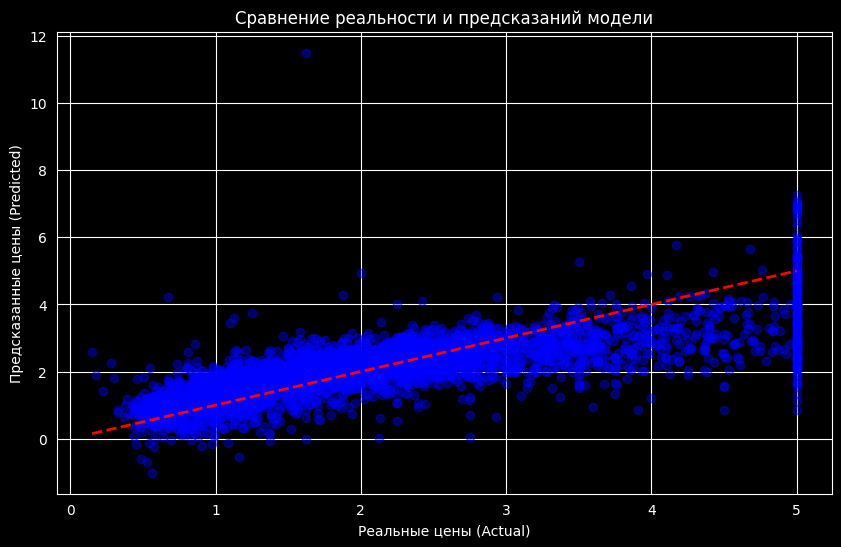

In [11]:
import matplotlib.pyplot as plt

# Настраиваем размер графика
plt.figure(figsize=(10, 6))

# Рисуем точки: по оси X - реальные цены, по оси Y - предсказанные
plt.scatter(y_test, predictions, alpha=0.4, color='blue')

# Рисуем идеальную прямую (где предсказание = реальности)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel('Реальные цены (Actual)')
plt.ylabel('Предсказанные цены (Predicted)')
plt.title('Сравнение реальности и предсказаний модели')
plt.grid(True)
plt.show()

In [9]:
# Создаем таблицу с весами
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coefficients.sort_values(by='Coefficient', ascending=False))

            Coefficient
AveBedrms      0.783145
MedInc         0.448675
HouseAge       0.009724
Population    -0.000002
AveOccup      -0.003526
AveRooms      -0.123323
Latitude      -0.419792
Longitude     -0.433708


In [10]:
from sklearn.ensemble import RandomForestRegressor

# Создаем модель (n_estimators=100 значит, что мы построим 100 деревьев)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Обучаем (это может занять на пару секунд больше, чем линейная регрессия)
rf_model.fit(X_train, y_train)

# Предсказываем
rf_preds = rf_model.predict(X_test)

# Считаем метрики
print(f"Random Forest R^2: {r2_score(y_test, rf_preds):.4f}")
print(f"Random Forest MSE: {mean_squared_error(y_test, rf_preds):.4f}")

Random Forest R^2: 0.8051
Random Forest MSE: 0.2554


/tmp/ipykernel_209103/21061581.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis")


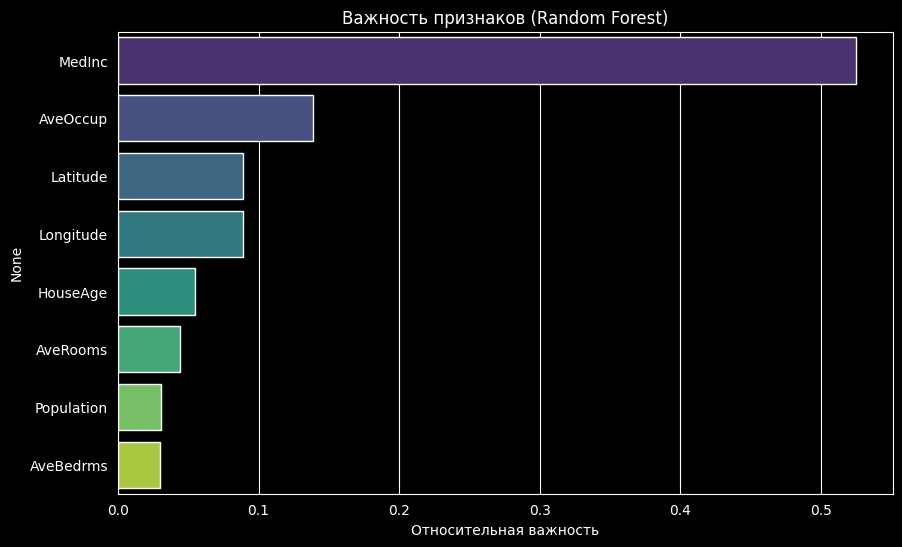

In [13]:
import numpy as np

# Получаем важность признаков из обученной модели
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Визуализируем
plt.figure(figsize=(10, 6))
plt.title("Важность признаков (Random Forest)")
sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis")
plt.xlabel("Относительная важность")
plt.show()

In [14]:
def predict_house_price(model, features_names):
    print("--- Введите параметры дома для оценки ---")

    # Создаем пустой словарь для данных
    input_data = {}

    # Пример средних значений из датасета для подсказки
    # MedInc: 3.5, HouseAge: 28, AveRooms: 5, AveBedrms: 1,
    # Population: 1400, AveOccup: 3, Lat: 35.6, Long: -119.5

    input_data['MedInc'] = [float(input("Медианный доход в районе (в $10к, напр. 5.0): "))]
    input_data['HouseAge'] = [float(input("Возраст дома (лет): "))]
    input_data['AveRooms'] = [float(input("Среднее кол-во комнат: "))]
    input_data['AveBedrms'] = [float(input("Среднее кол-во спален: "))]
    input_data['Population'] = [float(input("Население района: "))]
    input_data['AveOccup'] = [float(input("Среднее число жильцов: "))]
    input_data['Latitude'] = [float(input("Широта (напр. 34.0): "))]
    input_data['Longitude'] = [float(input("Долгота (напр. -118.0): "))]

    # Превращаем в DataFrame, чтобы модель "узнала" структуру
    user_df = pd.DataFrame(input_data)

    # Предсказание
    prediction = model.predict(user_df)[0]

    print(f"\n--- РЕЗУЛЬТАТ ---")
    print(f"Ориентировочная стоимость: ${prediction * 100000:,.0f}")

# Запускаем!
predict_house_price(rf_model, X.columns)

--- Введите параметры дома для оценки ---

--- РЕЗУЛЬТАТ ---
Ориентировочная стоимость: $367,665
